# New Notebook

Start here.


In [20]:
import os

import pandas as pd

# Load data (expects to be run from the Final_Project folder)
data_path = "class_data.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Could not find {os.path.abspath(data_path)}. Current working dir: {os.getcwd()}"
    )

df = pd.read_csv(data_path)

# Keep only the visualization columns we care about
# (Temperature is used later to split into low/high test temperature subsets.)
temp_col_candidates = ["Test Temperature Actual (°F)", "Test Temperature Actual (F)"]
temp_col = next((c for c in temp_col_candidates if c in df.columns), None)
if temp_col is None:
    raise KeyError(
        f"Could not find a test temperature column. Tried: {temp_col_candidates}. Available columns: {list(df.columns)}"
    )

viz_cols = [
    "O2",
    "Particulate",
    "Input Velocity (m/s)",
    "Coefficient of Restitution",
    temp_col,
]
missing = [c for c in viz_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}. Available columns: {list(df.columns)}")

df_viz = df[viz_cols].copy()

# Quick preview
print("df shape:", df.shape)
print("df_viz shape:", df_viz.shape)
display(df_viz.head())
display(pd.DataFrame({"dtype": df_viz.dtypes, "n_missing": df_viz.isna().sum()}))


df shape: (1961, 13)
df_viz shape: (1961, 5)


,O2,Particulate,Input Velocity (m/s),Coefficient of Restitution,Test Temperature Actual (F)
0,0,Ti,134.117822,0.202675,80.4
1,0,Ti,224.234313,0.139226,80.4
2,0,Ti,209.808077,0.163995,80.4
3,0,Ti,231.487995,0.145941,80.4
4,0,Ti,222.445604,0.139142,80.4


,dtype,n_missing
O2,int64,0
Particulate,object,0
Input Velocity (m/s),float64,0
Coefficient of Restitution,float64,0
Test Temperature Actual (F),float64,0


In [21]:
mask = (df_viz["Particulate"] == "Ti") & (df_viz["O2"] == 1)

df_ti_02 = df_viz.loc[mask].copy()
print("Count (Particulate == 'Ti' and O2 == 1):", len(df_ti_02))

# Split into low/high temperature subsets
# Note: temp_col is defined in the previous cell.
df_ti_o2_lowT = df_ti_02.loc[df_ti_02[temp_col] < 300].copy()
df_ti_o2_highT = df_ti_02.loc[df_ti_02[temp_col] > 300].copy()

print("df_ti_o2_lowT count:", len(df_ti_o2_lowT))
print("df_ti_o2_highT count:", len(df_ti_o2_highT))


Count (Particulate == 'Ti' and O2 == 1): 565
df_ti_o2_lowT count: 217
df_ti_o2_highT count: 348


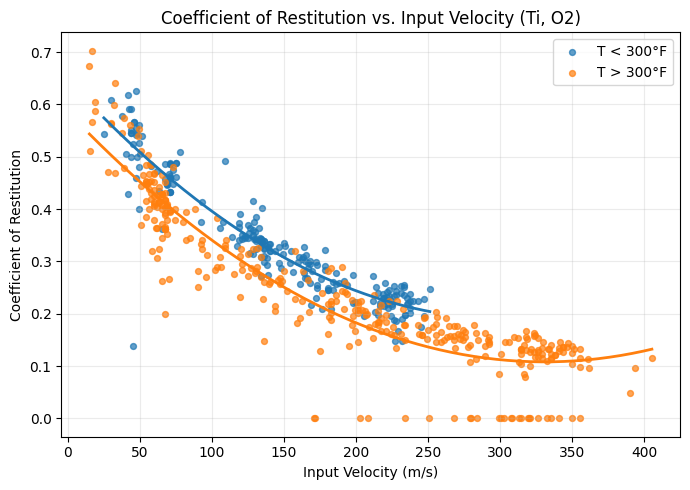

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x_col = "Input Velocity (m/s)"
y_col = "Coefficient of Restitution"

low = df_ti_o2_lowT.dropna(subset=[x_col, y_col])
high = df_ti_o2_highT.dropna(subset=[x_col, y_col])

plt.figure(figsize=(7, 5))

# Scatter series
plt.scatter(low[x_col], low[y_col], s=18, alpha=0.7, label="T < 300°F")
plt.scatter(high[x_col], high[y_col], s=18, alpha=0.7, label="T > 300°F")

# Trendlines (quadratic fit)
degree = 2

if len(low) >= degree + 1:
    coeffs = np.polyfit(low[x_col], low[y_col], degree)
    poly = np.poly1d(coeffs)
    x_line = np.linspace(low[x_col].min(), low[x_col].max(), 200)
    plt.plot(x_line, poly(x_line), linewidth=2)

if len(high) >= degree + 1:
    coeffs = np.polyfit(high[x_col], high[y_col], degree)
    poly = np.poly1d(coeffs)
    x_line = np.linspace(high[x_col].min(), high[x_col].max(), 200)
    plt.plot(x_line, poly(x_line), linewidth=2)

plt.xlabel("Input Velocity (m/s)")
plt.ylabel("Coefficient of Restitution")
plt.title("Coefficient of Restitution vs. Input Velocity (Ti, O2)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
